In [3]:
import sys
sys.path.append('..')

In [4]:
import os
import pandas as pd
import numpy as np
from utils import *
import seaborn as sns
sns.set_style("whitegrid")
from sklearn.preprocessing import LabelEncoder

In [5]:
data = pd.read_csv('Clean_Dataset.csv')

In [6]:
data

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [7]:
data.isnull().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [8]:
data.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [9]:
for column in ["source_city", "destination_city", "airline", "arrival_time", "departure_time", "stops", "class"]:
    encoder = LabelEncoder()
    data[column] = encoder.fit_transform(data[column])

In [10]:
flights_filtered = data['flight'].value_counts().to_frame().query("count>100").reset_index()["flight"].values.tolist()
data = data[data['flight'].isin(flights_filtered)]
data.reset_index(drop=True, inplace=True)

In [11]:
data.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,4,SG-8709,2,2,2,5,5,1,2.17,1,5953
1,1,4,SG-8157,2,1,2,4,5,1,2.33,1,5953
2,3,5,UK-995,2,4,2,0,5,1,2.25,1,5955
3,4,5,UK-963,2,4,2,4,5,1,2.33,1,5955
4,5,5,UK-945,2,4,2,0,5,1,2.33,1,5955


In [12]:
encoder = LabelEncoder()
data['flight'] = encoder.fit_transform(data['flight'])

/tmp/ipykernel_12145/4015715620.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['flight'] = encoder.fit_transform(data['flight'])


<Axes: title={'center': 'Price Distribution'}, ylabel='Frequency'>

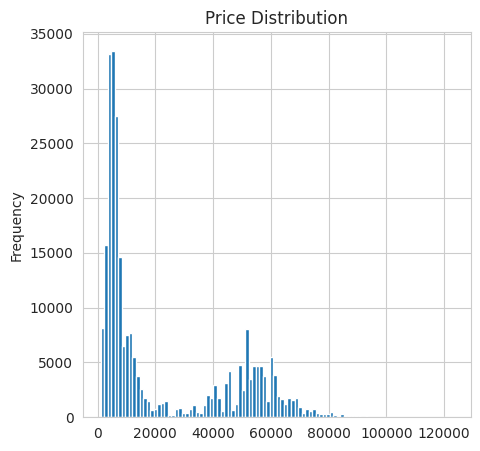

In [13]:
data['price'].plot(kind='hist', bins=100, figsize=(5, 5), title='Price Distribution')

In [14]:
data.drop(['Unnamed: 0'], axis=1, inplace=True)

/tmp/ipykernel_12145/4270661198.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(['Unnamed: 0'], axis=1, inplace=True)


In [15]:
data.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,4,425,2,2,2,5,5,1,2.17,1,5953
1,4,420,2,1,2,4,5,1,2.33,1,5953
2,5,553,2,4,2,0,5,1,2.25,1,5955
3,5,543,2,4,2,4,5,1,2.33,1,5955
4,5,535,2,4,2,0,5,1,2.33,1,5955


In [16]:
data.shape

(264236, 11)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(data)

data_scaled = scaler.transform(data)

In [18]:
data_scaled.shape

(264236, 11)

In [19]:
data_scaled = pd.DataFrame(data_scaled, columns=data.columns)

In [20]:
# data_scaled['price'] = data['price'].copy()

In [21]:
data_scaled.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0.435224,0.502081,-0.333058,-0.254532,2.849544,1.095262,1.390614,0.733094,-1.498278,-1.84068,-0.721573
1,0.435224,0.471906,-0.333058,-0.824594,2.849544,0.517965,1.390614,0.733094,-1.475807,-1.84068,-0.721573
2,0.960900,1.274565,-0.333058,0.885592,2.849544,-1.791223,1.390614,0.733094,-1.487042,-1.84068,-0.721488
3,0.960900,1.214214,-0.333058,0.885592,2.849544,0.517965,1.390614,0.733094,-1.475807,-1.84068,-0.721488
4,0.960900,1.165934,-0.333058,0.885592,2.849544,-1.791223,1.390614,0.733094,-1.475807,-1.84068,-0.721488


In [22]:
data_scaled.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [29]:
data_scaled.to_feather("reg_data.feather")